In [1]:
import polars as pl 
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow as pa
import pyarrow.parquet as pq

### Contexto

Os dados selecionados para análise são referentes a diversos e-commerce do Paquistão no período de março de 2016 até agosto de 2018 e nesse relatório será considerado como se todos os dados fossem referentes a apenas um e-commerce com o intuito de entender os pontos principais na área de vendas e também fazer comparações com os dados do olist.

Para descobrir o valor bruto de cada pedido realizado, multipliquei o preço dos produtos com a quantidade pedida pelo cliente e coloquei esse valor em uma nova coluna na tabela chama valor_venda_bruto.

In [2]:

parquet_location = "../Parte_2/pakistan_ecommerce_dataset_POLARS.parquet"

# Adição da coluna valor_venda_bruto (para ter o valor de cada pedido)
'''
query = pl.scan_parquet(parquet_location).with_columns(
    (pl.col('price') * pl.col('qty_ordered')).alias('valor_venda_bruto')
).collect() # O collect transforma em dataframe.

query.write_parquet(parquet_location)
'''

inicial = pl.scan_parquet(parquet_location)


Buscando entender como está distribuído os dados do dataset, fiz uma tabela que mostra a relação entre quantidade de pedidos com os status e sua porcentagem em relação ao total de pedidos realizados.

In [3]:
total = inicial.select(pl.len()).collect()[0, 0]

tabela_status = (
    inicial.group_by("status")
    .agg(pl.len().alias("contagem"))
    .with_columns(
        ((pl.col("contagem") / total) * 100).round(2).alias("percentual (%)")
    )
    .sort("contagem", descending=True)
).collect()

# 2. Configurando o Polars para imprimir a tabela inteira sem cortes
with pl.Config(tbl_rows=-1, tbl_cols=-1, fmt_str_lengths=50):
    print("--- RESUMO DE STATUS DOS PEDIDOS (PAQUISTÃO) ---")
    print(tabela_status)

--- RESUMO DE STATUS DOS PEDIDOS (PAQUISTÃO) ---
shape: (17, 3)
┌────────────────┬──────────┬────────────────┐
│ status         ┆ contagem ┆ percentual (%) │
│ ---            ┆ ---      ┆ ---            │
│ str            ┆ u32      ┆ f64            │
╞════════════════╪══════════╪════════════════╡
│ complete       ┆ 233685   ┆ 39.98          │
│ canceled       ┆ 201249   ┆ 34.43          │
│ received       ┆ 77290    ┆ 13.22          │
│ order_refunded ┆ 59529    ┆ 10.18          │
│ refund         ┆ 8050     ┆ 1.38           │
│ cod            ┆ 2859     ┆ 0.49           │
│ paid           ┆ 1159     ┆ 0.2            │
│ closed         ┆ 494      ┆ 0.08           │
│ payment_review ┆ 57       ┆ 0.01           │
│ pending        ┆ 48       ┆ 0.01           │
│ processing     ┆ 33       ┆ 0.01           │
│ holded         ┆ 31       ┆ 0.01           │
│ null           ┆ 15       ┆ 0.0            │
│ fraud          ┆ 10       ┆ 0.0            │
│ pending_paypal ┆ 7        ┆ 0.0          

### Filtrar os pedidos
O valor real dos produtos vendidos, ou seja, o valor que realmente o ecommerce recebeu está concentrado nos pedidos que estão com status complete, received e paid. Então vamos filtrar os dados apenas com esses status para analisar os valores. Além disso, quero apenas pedidos que tem valor de venda > 0.

In [4]:
# Pegar apenas os dados que interessa para análise
# Lista de status que trouxeram dinheiro
status_validos = ['complete', 'paid', 'received']
df_validos = pl.scan_parquet(parquet_location).filter(
    (pl.col('status').is_in(status_validos)) &
    (pl.col('valor_venda_bruto') > 0)
).with_columns(
    pl.col('created_at')
    .str.strptime(pl.Date, "%m/%d/%Y")
    .alias("DATA_REF")
).collect()

total_validos = len(df_validos)


valor_total_vendas = df_validos['valor_venda_bruto'].sum()
print(f"Total de pedidos: {total}")
print(f"Total de pedidos válidos para análise: {total_validos}")
print(f"Quantidade de pedidos retirados para analisar valor de venda bruto: {total - total_validos}")
display(f"O valor de venda total do ecommerce =  {valor_total_vendas} rupias <=> R$ {valor_total_vendas * 0.057}")


Total de pedidos: 584524
Total de pedidos válidos para análise: 311394
Quantidade de pedidos retirados para analisar valor de venda bruto: 273130


'O valor de venda total do ecommerce =  1369198514.26 rupias <=> R$ 78044315.31282'

Para entender de forma precisa o valor bruto de vendas dos pedidos, foi necessário ser desconsiderado 273.130 pedidos do total de 584.524. O quantitativo considerado válido são de 311.394, que são os pedidos com status de completo, pago ou recebido e com valor total bruto maior do que 0.

### Outliers



In [5]:
# Vou ter que usar o polars para fazer as medidas descritivas dos dados da coluna valor_venda_bruto

# Calculando outliers
q1 = df_validos['valor_venda_bruto'].quantile(0.25)
q3 = df_validos['valor_venda_bruto'].quantile(0.75)
IQR = q3 - q1

limite_superior = q3 + (1.5 * IQR) # Limite superior dos pedidos validos

df_outliers = df_validos.filter(pl.col('valor_venda_bruto') > limite_superior)
faturamento_outliers = df_outliers['valor_venda_bruto'].sum()

display(df_outliers)
display(f"O faturamento dos outliers é de {faturamento_outliers} rupias")

relacao_faturamento_outliers = (faturamento_outliers / valor_total_vendas) * 100
display(f"Os outliers representam {relacao_faturamento_outliers:.2n}% do faturamento total do ecommerce. ")
display(f"Outliers= {len(df_outliers)} | Pedidos normais= {len(df_validos) - len(df_outliers)}")

print(f"Limite Superior: {limite_superior}")



item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,discount_amount,payment_method,Working_Date,BI_Status,MV,Year,Month,Customer_Since,M-Y,FY,Customer_ID,valor_venda_bruto,DATA_REF
i64,str,str,str,f64,i64,f64,i64,str,str,f64,str,str,str,str,i64,i64,str,str,str,i64,f64,date
211142,"""complete""","""7/1/2016""","""GFC_Pedestal Myga Cross Base (…",5500.0,1,5500.0,100147453,"""Appliances""","""\N""",0.0,"""cod""","""7/1/2016""","""Net""","""5.500""",2016,7,"""2016-7""","""7-2016""","""FY17""",9,5500.0,2016-07-01
211168,"""complete""","""7/1/2016""","""Samsung Galaxy J5""",20999.0,1,20999.0,100147466,"""Mobiles & Tablets""","""R-FSD-58130""",0.0,"""cod""","""7/1/2016""","""Net""","""20.999""",2016,7,"""2016-7""","""7-2016""","""FY17""",20,20999.0,2016-07-01
211204,"""complete""","""7/1/2016""","""Orient_OR-6057 GX LGFD LV""",45250.0,1,45250.0,100147488,"""Appliances""","""R-KHS-104405""",0.0,"""cod""","""7/1/2016""","""Net""","""45.250""",2016,7,"""2016-7""","""7-2016""","""FY17""",38,45250.0,2016-07-01
211207,"""complete""","""7/1/2016""","""asimjofaeanew_5A""",5597.0,1,5597.0,100147490,"""Women's Fashion""","""R-KHS-104405""",0.0,"""cod""","""7/1/2016""","""Net""","""5.597""",2016,7,"""2016-7""","""7-2016""","""FY17""",40,5597.0,2016-07-01
211265,"""complete""","""7/1/2016""","""LC_3349668508587""",7400.0,1,12150.0,100147533,"""Beauty & Grooming""","""R-KHW-104406""",0.0,"""cod""","""7/1/2016""","""Net""","""7.400""",2016,7,"""2016-7""","""7-2016""","""FY17""",13,7400.0,2016-07-01
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
904920,"""paid""","""8/27/2018""","""BAGCLI5ACDE338ACDC9""",1300.0,5,6750.0,100562226,"""Beauty & Grooming""",null,0.0,"""Payaxis""","""8/27/2018""","""Valid""","""6.500""",2018,8,"""2018-8""","""8-2018""","""FY19""",115284,6500.0,2018-08-27
905028,"""paid""","""8/27/2018""","""ENTECO5A7FE80D6C830""",20599.0,1,0.0,100562284,"""Entertainment""","""R-GUJ-106946""",0.0,"""customercredit""","""8/27/2018""","""Valid""","""20.599""",2018,8,"""2018-3""","""8-2018""","""FY19""",92669,20599.0,2018-08-27
905063,"""paid""","""8/27/2018""","""MATHUA5A804E47B2650""",30499.0,1,31591.0,100562293,"""Mobiles & Tablets""",null,0.0,"""bankalfalah""","""8/27/2018""","""Valid""","""30.499""",2018,8,"""2018-8""","""8-2018""","""FY19""",115304,30499.0,2018-08-27


'O faturamento dos outliers é de 1136653563.95 rupias'

'Os outliers representam 83% do faturamento total do ecommerce. '

'Outliers= 54857 | Pedidos normais= 256537'

Limite Superior: 5113.0


In [6]:
pk_validos = pl.scan_parquet('../Parte_2/pakistan_ecommerce_dataset_POLARS.parquet').filter(
        (pl.col('status').is_in(status_validos)) &
    (pl.col('valor_venda_bruto') > 0)
).with_columns([
    pl.when(pl.col('valor_venda_bruto') > limite_superior)
    .then(pl.lit('Premium'))
    .otherwise(pl.lit('Normal'))
    .alias('segmento')
]).group_by('segmento').agg([
    pl.len().alias('qtd_pedidos'),
    pl.col('valor_venda_bruto').sum().alias('faturamento')
]).collect()

# Calcular porcentagens
total_ped_pk = pk_validos['qtd_pedidos'].sum()
total_fat_pk = pk_validos['faturamento'].sum()

pk_validos = pk_validos.with_columns([
    (pl.col('qtd_pedidos') / total_ped_pk * 100).alias('percentual_pedidos'),
    (pl.col('faturamento') / total_fat_pk * 100).alias('percentual_faturamento')
])

display(pk_validos)

segmento,qtd_pedidos,faturamento,percentual_pedidos,percentual_faturamento
str,u32,f64,f64,f64
"""Premium""",54857,1.1367e9,17.616589,83.01598
"""Normal""",256537,2.3254e8,82.383411,16.98402


Como os outliers dos pedidos, ou seja, os pedidos cujo os valores ultrapassam 5113 rupias (288.53 reais) representam 83% do faturamento total do ecommerce. O que realmento consegue financiar e manter a empresa funcionando são os pedidos 'premium' que são vendidos.
Isso comprova e reafirma com a analise do ecommerce olist que os produtos mais caros,podendo ser considerados 'premium', tem um impacto financeiro
enorme em lojas de ecommerce, muito mais do que os produtos que são normalmente vendidos (mais baratos). 

### Comparativo de dependência dos pedidos 'premium'
Você notou que no Paquistão a dependência é de 83%, enquanto na Olist era de aproximadamente 37%?

Isso significa que o Paquistão é muito mais frágil que a Olist. Se os clientes premium do Paquistão pararem de comprar, a empresa quebra amanhã. Na Olist, ela ainda teria 63% da receita para tentar se manter.

In [7]:
categorias_outliers = df_outliers.group_by("category_name_1").agg([
    pl.len().alias("total_de_pedidos"),
    pl.col("valor_venda_bruto").sum().alias("faturamento_total_categoria"),
    pl.col("valor_venda_bruto").min().alias("menor_valor_pedido"),
    pl.col("valor_venda_bruto").max().alias("maior_valor_pedido"),
    pl.col('valor_venda_bruto').mean().alias('valor_médio')
]).sort("faturamento_total_categoria", descending=True)

print("Tabela que contém os pedidos que são os outliers superiores dividos por categoria")
display(categorias_outliers)

Tabela que contém os pedidos que são os outliers superiores dividos por categoria


category_name_1,total_de_pedidos,faturamento_total_categoria,menor_valor_pedido,maior_valor_pedido,valor_médio
str,u32,f64,f64,f64,f64
"""Mobiles & Tablets""",26551,6.0574e8,5145.0,8.944e6,22814.261841
"""Appliances""",10911,2.0732e8,5125.0,236850.0,19001.288313
"""Entertainment""",9172,2.0479e8,5122.0,1.039479e6,22327.331476
"""Computing""",1841,3.9656e7,5185.0,322500.0,21540.245894
"""Others""",2307,3.6802024e7,6000.0,60000.0,15952.329432
…,…,…,…,…,…
"""Health & Sports""",114,1.22677e6,5200.0,82000.0,10761.140351
"""Kids & Baby""",51,455843.65,5250.0,25499.0,8938.110784
"""Soghaat""",15,140633.0,5398.0,16500.0,9375.533333


É perceptível que a categoria 'Mobiles & Tablets'(celulares e tablets) é principal responsável pelas vendas mais caras do ecommerce.
A categoria de Appliances(Eltrodomésticos) aparece logo em seguida com a de entretenimento.
TOP três categorias que mais faturaram nos outliers superiores:
1. Mobiles & Tablets
2. Appliances
3. Entertainment


### Perfil do Consumidor Premium: Paquistão
O público-alvo do segmento **Premium** no Paquistão possui um perfil estritamente tecnológico, com consumo concentrado em bens duráveis e eletrônicos de ponta. 

#### Estratégias para Alavancar as Vendas:
Para converter o potencial de consumo deste perfil em receita incremental, recomendam-se as seguintes medidas:

* **Parcelamento Sem Juros:** Viabilizar a aquisição de itens de alto valor (Appliances) para o público de classe média, facilitando o upgrade para o segmento Premium.
* **Segurança e Logística:** Oferecer **Frete Grátis com Seguro** e **Garantia Estendida** da loja, reduzindo a fricção na compra de itens sensíveis e caros.
* **Venda Cruzada (Cross-selling):** Implementar promoções integradas entre categorias (ex: desconto em fones de ouvido na compra de um Smartphone), explorando o ecossistema tecnológico do cliente.

In [8]:
out_faturamento_celulares = categorias_outliers["faturamento_total_categoria"][0] # Pega o valor do faturamento total de Mobiles & Tablets
percentagem_faturamento_celulares_outliers = (out_faturamento_celulares / valor_total_vendas) * 100
print(f"A parcela de vendas da categoria 'Mobiles & Tablets' dos outliers superiores representa {percentagem_faturamento_celulares_outliers:.2n}% do faturamento total.") 

A parcela de vendas da categoria 'Mobiles & Tablets' dos outliers superiores representa 44% do faturamento total.


## Comparativo entre as vendas de produtos normais e produtos caros durante o ano

In [9]:
# Preciso somar valor venda bruta < limite_superior para produtos normais e > limite_superior para os produtos mais caros.
# Coluna month - faturamento_mensal_normal - faturamento_mensal_caros
#criar uma coluna que trunca a data para o início do mês
comparativo_vendas = (
    df_validos
    .with_columns([
        pl.col('DATA_REF').dt.truncate("1mo").alias("MES_ANO_REF")
    ])
    #Agora agrupamos por essa nova coluna de mês/ano
    .group_by('MES_ANO_REF')
    .agg([
        # Produtos normais
        pl.when(pl.col('valor_venda_bruto') <= limite_superior)
        .then(pl.col('valor_venda_bruto'))
        .otherwise(0)
        .sum()
        .alias('faturamento_mensal_normal'),

        # Produtos caros (outliers)
        pl.when(pl.col('valor_venda_bruto') > limite_superior)
        .then(pl.col('valor_venda_bruto'))
        .otherwise(0)
        .sum()
        .alias('faturamento_mensal_caros')
    ])
    #Ordenamos pela data truncada (funciona perfeitamente por ser tipo data)
    .sort('MES_ANO_REF', descending=False)
)

print(comparativo_vendas.tail(12))

# Fazer um gráfico de linhas comparando os faturamentos dos 2 tipos de pedidos ao longo do ano.

shape: (12, 3)
┌─────────────┬───────────────────────────┬──────────────────────────┐
│ MES_ANO_REF ┆ faturamento_mensal_normal ┆ faturamento_mensal_caros │
│ ---         ┆ ---                       ┆ ---                      │
│ date        ┆ f64                       ┆ f64                      │
╞═════════════╪═══════════════════════════╪══════════════════════════╡
│ 2017-09-01  ┆ 3.0756e6                  ┆ 6.1213e6                 │
│ 2017-10-01  ┆ 5.4798e6                  ┆ 2.2004e7                 │
│ 2017-11-01  ┆ 2.8353e7                  ┆ 3.1938e8                 │
│ 2017-12-01  ┆ 6.9607e6                  ┆ 1.2921e7                 │
│ 2018-01-01  ┆ 6.2934e6                  ┆ 1.7812e7                 │
│ …           ┆ …                         ┆ …                        │
│ 2018-04-01  ┆ 5.9006e6                  ┆ 1.3550e7                 │
│ 2018-05-01  ┆ 1.0032e7                  ┆ 1.2432e8                 │
│ 2018-06-01  ┆ 5.9790e6                  ┆ 2.7214e7          

In [10]:
print(comparativo_vendas.filter(pl.col('MES_ANO_REF').dt.month() == 11))

#1.3676e8  max 2018

shape: (2, 3)
┌─────────────┬───────────────────────────┬──────────────────────────┐
│ MES_ANO_REF ┆ faturamento_mensal_normal ┆ faturamento_mensal_caros │
│ ---         ┆ ---                       ┆ ---                      │
│ date        ┆ f64                       ┆ f64                      │
╞═════════════╪═══════════════════════════╪══════════════════════════╡
│ 2016-11-01  ┆ 2.5484e7                  ┆ 5.8574e7                 │
│ 2017-11-01  ┆ 2.8353e7                  ┆ 3.1938e8                 │
└─────────────┴───────────────────────────┴──────────────────────────┘


Com essa visão do faturamento de pedidos normais e caros agrupados por mês, podemos verificar e tentar compreender por que o faturamento de determinado segmento é menor ou maior em meses especifícos.

**Faturamento mensal dos pedidos caros**: O pico de vendas desse segmento em em sua maioria no mês de novembro, muito por conta do período de BLACK FRIDAY, afinal é o momento em que esses produtos mais caros recebem descontos e também em parte seja por conta de ser um momento em que os trabalhadores paquistaneses recebem o seu bônus anual.

Em grandes organizações e multinacionais no Paquistão, é comum o pagamento de um "salário do 13º mês" como bônus de final de ano ou bônus de Eid (festividade religiosa) para atrair e reter talentos.

Como o mês de novembro é o que mais a empresa consegue realizar vendas desses produtos premium, é necessário montar estratégias para que não ocorre poucas vendas desse segmento, afinal 83% de valor de venda bruto da empresa depende desse segmento. 

Medidas como parcelamentos sem juros para os outliers irá atrair mais público para esses produtos mais caros e promoções cruzadas entre a categoria de celulares e tablets com a de entretenimento ou até mesmo com a de eletrodomésticos pode fomentar o interesse do cliente a realizar a comprar e consequentemente o faturamento do ecommerce.


### Análise de cancelamentos dos pedidos

In [11]:
df_analise = inicial.with_columns(
    pl.when(pl.col("valor_venda_bruto") > limite_superior)
    .then(pl.lit("Premium"))
    .otherwise(pl.lit("Normal"))
    .alias("segmento")
)


taxa_cancelamento = (
    df_analise.group_by("segmento")
    .agg([
        pl.len().alias("total_pedidos"),
        pl.col("status").filter(pl.col("status") == "canceled").count().alias("cancelados")
    ])
    .with_columns(
        (pl.col("cancelados") / pl.col("total_pedidos") * 100).round(2).alias("taxa_cancelamento_%")
    )
).collect()

print(taxa_cancelamento)

shape: (2, 4)
┌──────────┬───────────────┬────────────┬─────────────────────┐
│ segmento ┆ total_pedidos ┆ cancelados ┆ taxa_cancelamento_% │
│ ---      ┆ ---           ┆ ---        ┆ ---                 │
│ str      ┆ u32           ┆ u32        ┆ f64                 │
╞══════════╪═══════════════╪════════════╪═════════════════════╡
│ Premium  ┆ 142362        ┆ 75812      ┆ 53.25               │
│ Normal   ┆ 442162        ┆ 125437     ┆ 28.37               │
└──────────┴───────────────┴────────────┴─────────────────────┘


Os pedidos premium como visto anteriormento, são responsáveis por 80% do faturamento do ecommerse, o cancelamento de metade dos pedidos desse segmento é um impacto negativo na saúde financeira do ecommerce e vale entender o por que dos produtos mais caros estarem sendo cancelados com tanta frequência.


No dataset do Paquistão, tentativas falhas de pagamento digital muitas vezes são registradas como canceled, inflando a estatística.

### Impacto dos cancelamentos via COD

In [12]:
# payment_method
df_analise_pagamentos = inicial.group_by('payment_method').agg([
    pl.len().alias("total_pedidos"),
    pl.col('status').filter(pl.col('status') == 'canceled').count().alias('cancelados')
    ]).with_columns(
    (pl.col("cancelados") / pl.col("total_pedidos") * 100).round(2).alias("taxa_cancelamento_%")
    ).sort('total_pedidos', descending=True)


df_pagamentos_premium = (
    inicial
    .filter(pl.col('valor_venda_bruto') > limite_superior) # O filtro vem PRIMEIRO
    .group_by('payment_method')
    .agg([
        pl.len().alias("total_pedidos_premium"),
        pl.col('status').filter(pl.col('status') == 'canceled').count().alias('cancelados_premium')
    ])
    .with_columns(
        (pl.col("cancelados_premium") / pl.col("total_pedidos_premium") * 100)
        .round(2)
        .alias("taxa_cancelamento_premium_%")
    )
    .sort('total_pedidos_premium', descending=True)
)

print("Taxa de cancelamentos por método de pagamentos")
display(df_analise_pagamentos.collect())
print("Taxa de cancelamentos por método de pagamentos dos pedidos premium.")
display(df_pagamentos_premium.collect().head(10))

Taxa de cancelamentos por método de pagamentos


payment_method,total_pedidos,cancelados,taxa_cancelamento_%
str,u32,u32,f64
"""cod""",271960,21753,8.0
"""Payaxis""",97641,61267,62.75
"""Easypay""",82900,52040,62.77
"""jazzwallet""",35145,16933,48.18
"""easypay_voucher""",31176,12189,39.1
…,…,…,…
"""mygateway""",669,652,97.46
"""internetbanking""",472,286,60.59
"""productcredit""",125,10,8.0


Taxa de cancelamentos por método de pagamentos dos pedidos premium.


payment_method,total_pedidos_premium,cancelados_premium,taxa_cancelamento_premium_%
str,u32,u32,f64
"""Payaxis""",35584,24082,67.68
"""Easypay""",31128,19801,63.61
"""cod""",26494,6371,24.05
"""easypay_voucher""",21724,7529,34.66
"""bankalfalah""",10405,7946,76.37
"""jazzvoucher""",6402,3304,51.61
"""Easypay_MA""",4073,2889,70.93
"""jazzwallet""",4021,2715,67.52
"""customercredit""",1003,2,0.2


O COD (cash on delivery) apresenta 24.05% de taxa de cancelamento no segmento de pedidos premium. 

COD -> Forma de pagamento que permite com que o cliente apenas pague o pedido quanto o mesmo chegar em sua residência, além disso, cabe a decisão dele se aceita ou cancela a transação no momento da entrega. Essa modalidade transfere todo o risco para o lojista pois se houver cancelamentos o vendedor além de arcar com o custo da do envio precisa pagar o frete da volta. Em cima disso tudo, ele ainda fica com o produto preso em transporte, ou seja, não podendo realizar a venda novamente até estar em estoque novamente.

O frete de pedidos mais caros também vão ser mais custosos, afinal tais pedidos precisam ter mais cuidado com o transporte e a depender do tamanho vira uma bola de neve de custo para o vendedor.

Para evitar com que o cliente utilize essa forma de pagamento com frequência, é necessário implementar incentivos para as demais formas de pagamentos menos prejudiciais ao fornecedor, como o frete grátis ou descontos nos pedidos. Principalmente os pedidos com fretes mais elevados, pois se o cliente optar pelo COD, o fornecedor está correndo um risco maior.

### Correlação

**Pergunta de negócio:**  A categoria que mais vende é a que mais vai trazer valor de venda para o ecommerce?

In [13]:
df_pedidos = df_validos.group_by("category_name_1").agg([
    pl.len().alias("Qtd_pedidos"), # variavel x
    pl.col('valor_venda_bruto').mean().alias('valor_venda_medio')
]).sort('Qtd_pedidos', descending=True)

display(df_pedidos)
# 2. Calcular a Correlação de Pearson
correlacao = df_pedidos.select(
    pl.corr("Qtd_pedidos", 'valor_venda_medio', method='pearson').alias('r')
)

r= correlacao['r'][0]
r2 = r**2

print(f"\n--- Análise de Correlação por Categoria de produtos ---")
print(f"Coeficiente de Pearson (r): {r:.4f}")
print(f"Coeficiente de Determinação (r²): {r2:.4f}")

# Interpretação
if abs(r) < 0.3:
    print("Conclusão: Correlação FRACA. A quantidade de pedidos de uma categoria não influencia no valor médio de sua venda.")
elif abs(r) > 0.7:
    print("Conclusão: Correlação FORTE.")
else:
    print("Conclusão: Correlação MODERADA.")

category_name_1,Qtd_pedidos,valor_venda_medio
str,u32,f64
"""Men's Fashion""",52547,781.437474
"""Mobiles & Tablets""",50021,12567.489904
"""Women's Fashion""",33830,1659.213179
"""Beauty & Grooming""",27082,798.515222
"""Superstore""",26967,806.706931
…,…,…
"""Computing""",7165,6467.266726
"""\N""",3361,5399.505802
"""School & Education""",2155,473.874622



--- Análise de Correlação por Categoria de produtos ---
Coeficiente de Pearson (r): 0.1202
Coeficiente de Determinação (r²): 0.0144
Conclusão: Correlação FRACA. A quantidade de pedidos de uma categoria não influencia no valor médio de sua venda.


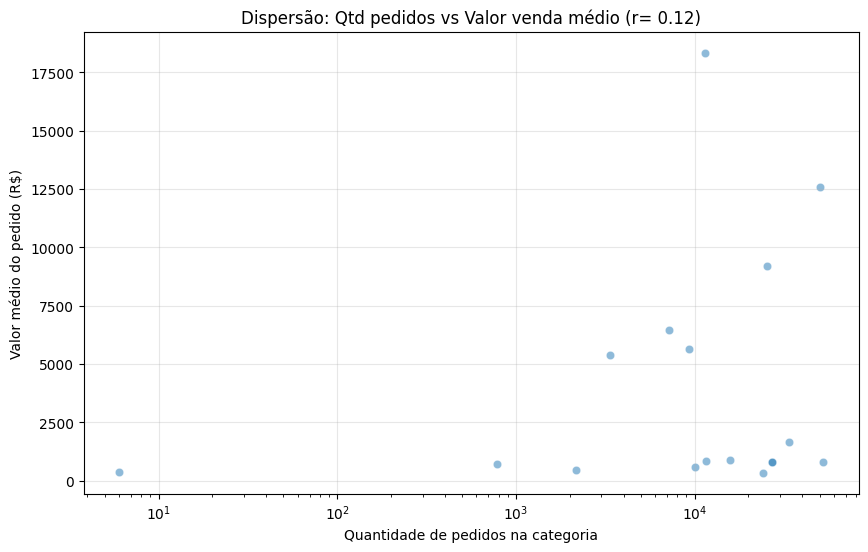

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data= df_pedidos.to_pandas(),
    x= 'Qtd_pedidos',
    y= 'valor_venda_medio',
    alpha=0.5
)

plt.title(f"Dispersão: Qtd pedidos vs Valor venda médio (r= {r:.2f})")
plt.xlabel('Quantidade de pedidos na categoria')
plt.ylabel('Valor médio do pedido (R$)')
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.show()